# Kaggle: Regression with an Abalone Dataset

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 12, 2026

## Two nonlinear regression models, diagnostics, interpretation, and submission files

**Competition:** [Playground Series S4E4](https://www.kaggle.com/competitions/playground-series-s4e4)  
**Response:** `Rings`  
**Primary metric:** Root Mean Squared Logarithmic Error (RMSLE)

This notebook uses the `train.csv`, `test.csv`, and `sample_submission.csv` provided by the Kaggle Competition.  It fits two nonlinear methods emphasized in *An Introduction to Statistical Learning with Applications in Python*:  (1) second-degree polynomial regression and (2) additive cubic regression splines.  It conducts exploratory data analysis (EDA), evaluates the models out of sample, investigates regression assumptions, interprets findings, and writes two Kaggle-ready submission files.

> **Reproducibility:** Place the three CSV files either beside this notebook or in an `upload/` subfolder.  Run all cells in ordee from top to bottom.  Random seeds are fixed.  The notebook does not require the Kaggle API.


## 1. Scholarly foundation

The target approximates abalone age through ring counts.  Prior biological research shows that growth and age relationships vary with sex, maturity, and physical dimensions, making strictly linear effects scientifically implausible (Nash et al., 1994).  The documented variation in growth and age relationships by sex, maturity, and physical dimensions motivates using flexible nonlinear functions for the measured dimensions and weights.

EDA is used to discover distributional shape, unusual observations, dependence, and modeling constraints before formal fitting.  Following Tukey (1977), plots and robust summaries are treated as tools for discovering structure rather than as decorative confirmations of a predetermined model.

Missingness must be investigated before modeling because complete-case deletion can reduce precision or introduce bias when missingness is systematic.  Multiple imputation provides a principled way to propagate uncertainty under an appropriate missing-at-random framework (Rubin, 1987).  These competition files contain no missing values; nevertheless, median and most-frequent imputers are retained inside each pipeline so the code remains valid if missing values appear in future scoring data.  Because no values are missing here, no observations are deleted and no imputed values affect the fitted results.


In [1]:
# Imports and reproducibility settings
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, SplineTransformer, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 30)


In [2]:
# Resolve the files from either the notebook directory or ./upload
def locate(name):
    candidates = [Path(name), Path("upload") / name]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {name}. Tried: {candidates}")

train_path = locate("train.csv")
test_path = locate("test.csv")
sample_path = locate("sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)

print("Files:", train_path, test_path, sample_path, sep="\n  ")
print(f"\nTrain shape: {train.shape}; test shape: {test.shape}; sample shape: {sample.shape}")
display(train.head())


Files:
  upload\train.csv
  upload\test.csv
  upload\sample_submission.csv

Train shape: (90615, 10); test shape: (60411, 9); sample shape: (60411, 2)


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


## 2. Data audit and exploratory analysis

The audit checks schema agreement, ID alignment, missingness, duplicates, category levels, nonpositive values, and target distribution.  The `id` field is an identifier rather than a biological measurement and is excluded from modeling.  The source uses duplicate-like weight labels; the notebook preserves the CSV column names to ensure exact reproducibility.


In [3]:
target = "Rings"
id_col = "id"
categorical = ["Sex"]
numeric = [c for c in test.columns if c not in [id_col] + categorical]

assert target in train.columns and target not in test.columns
assert list(sample.columns) == [id_col, target]
assert len(test) == len(sample)
assert test[id_col].equals(sample[id_col])
assert set(test.columns) == set(train.columns) - {target}

audit = pd.DataFrame({
    "train_dtype": train.dtypes.astype(str),
    "train_missing": train.isna().sum(),
    "train_unique": train.nunique(),
})
audit["test_missing"] = test.isna().sum().reindex(audit.index)
display(audit)
print("Exact duplicate training rows:", train.duplicated().sum())
print("Sex levels (train):", sorted(train["Sex"].unique()))
print("Sex levels (test): ", sorted(test["Sex"].unique()))
print("Nonpositive numeric predictor values (train):")
display((train[numeric] <= 0).sum().to_frame("count"))


,train_dtype,train_missing,train_unique,test_missing
id,int64,0,90615,0.0
Sex,object,0,3,0.0
Length,float64,0,157,0.0
Diameter,float64,0,126,0.0
Height,float64,0,90,0.0
Whole weight,float64,0,3175,0.0
Whole weight.1,float64,0,1799,0.0
Whole weight.2,float64,0,979,0.0
Shell weight,float64,0,1129,0.0
Rings,int64,0,28,NaN


Exact duplicate training rows: 0
Sex levels (train): ['F', 'I', 'M']
Sex levels (test):  ['F', 'I', 'M']
Nonpositive numeric predictor values (train):


,count
Length,0
Diameter,0
Height,6
Whole weight,0
Whole weight.1,0
Whole weight.2,0
Shell weight,0


,count,mean,std,min,25%,50%,75%,max
Length,90615.0,0.517098,0.118217,0.0750,0.4450,0.5450,0.6000,0.8150
Diameter,90615.0,0.401679,0.098026,0.0550,0.3450,0.4250,0.4700,0.6500
Height,90615.0,0.135464,0.038008,0.0000,0.1100,0.1400,0.1600,1.1300
Whole weight,90615.0,0.789035,0.457671,0.0020,0.4190,0.7995,1.0675,2.8255
Whole weight.1,90615.0,0.340778,0.204428,0.0010,0.1775,0.3300,0.4630,1.4880
Whole weight.2,90615.0,0.169422,0.100909,0.0005,0.0865,0.1660,0.2325,0.7600
Shell weight,90615.0,0.225898,0.130203,0.0015,0.1200,0.2250,0.3050,1.0050
Rings,90615.0,9.696794,3.176221,1.0000,8.0000,9.0000,11.0000,29.0000


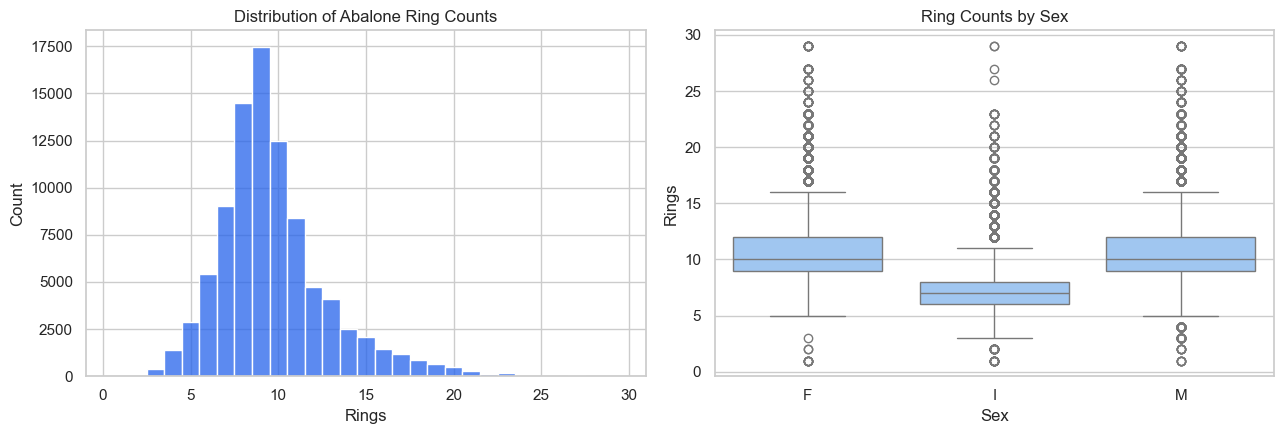

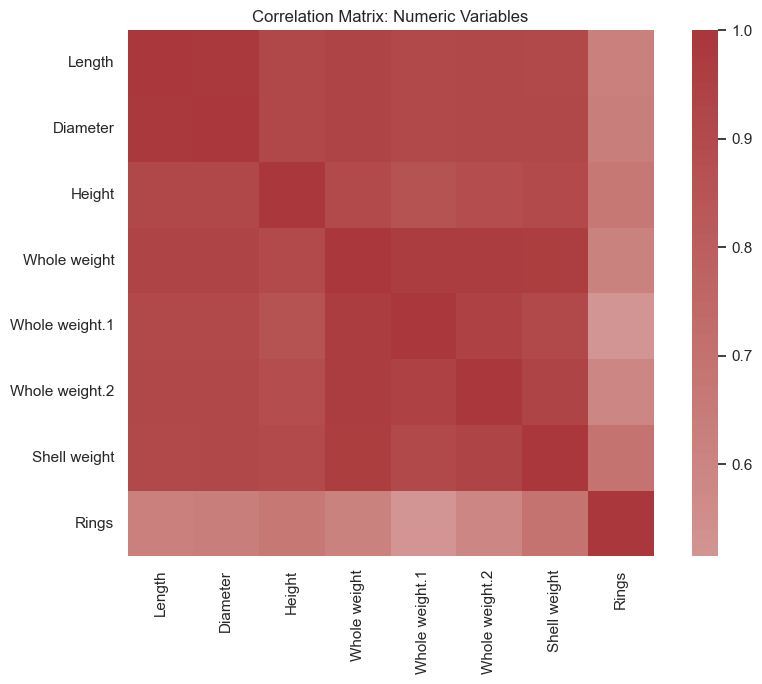

In [4]:
display(train[numeric + [target]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train[target], discrete=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribution of Abalone Ring Counts")
sns.boxplot(data=train, x="Sex", y=target, ax=axes[1], color="#93c5fd")
axes[1].set_title("Ring Counts by Sex")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(train[numeric + [target]].corr(), cmap="vlag", center=0, square=True)
plt.title("Correlation Matrix: Numeric Variables")
plt.tight_layout()
plt.show()


### EDA interpretation

After running the cell above, interpret the printed values and figures together.  Ring counts are positive and right-skewed, which supports evaluating predictions on the logarithmic scale used by RMSLE.  The size and weight measures are strongly correlated because they represent related aspects of the same organism.  This dependence creates multicollinearity for basis-expansion models; ridge regularization is therefore used to stabilize coefficients.  The sex categories encode maturity and biological differences, and are one-hot encoded.  Apparent extreme values are retained:  competition data can contain legitimate large specimens, and arbitrary deletion would change the target population.


## 3. Modeling design

Both candidates use the same split, preprocessing safeguards, and log-transformed response.  Fitting `log1p(Rings)` aligns training with RMSLE and guarantees nonnegative predictions after inverse transformation.

1. **Quadratic polynomial ridge regression** includes each numeric predictor, its square, and pairwise interactions.  It represents smooth global curvature but can be sensitive near predictor boundaries.
2. **Additive cubic regression spline ridge model** represents each numeric main effect with a cubic B-spline basis.  It permits local changes in slope while avoiding high-order global polynomials.  The additive specification is interpretable but does not automatically include interactions.

The held-out test subset provides final diagnostics.  Five-fold cross-validation on the remaining development sample is used for a fair model comparison.  The Kaggle test file is not used during selection.


In [5]:
X = train.drop(columns=[target, id_col])
y = train[target].astype(float)
X_kaggle = test.drop(columns=[id_col])

X_dev, X_valid, y_dev, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

numeric_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

poly_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
])
poly_pre = ColumnTransformer([
    ("numeric", poly_numeric, numeric),
    ("sex", categorical_pipe, categorical),
])

spline_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("spline", SplineTransformer(n_knots=6, degree=3, include_bias=False)),
    ("scale", StandardScaler()),
])
spline_pre = ColumnTransformer([
    ("numeric", spline_numeric, numeric),
    ("sex", categorical_pipe, categorical),
])

def log_target_model(preprocessor, alpha=10.0):
    reg = Pipeline([
        ("preprocess", preprocessor),
        ("ridge", Ridge(alpha=alpha)),
    ])
    return TransformedTargetRegressor(
        regressor=reg, func=np.log1p, inverse_func=np.expm1
    )

models = {
    "Quadratic polynomial": log_target_model(poly_pre, alpha=10.0),
    "Cubic regression splines": log_target_model(spline_pre, alpha=10.0),
}


In [6]:
# Five-fold cross-validation; sklearn's MSLE scorer is negated by convention
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "msle": "neg_mean_squared_log_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)
    fold_rmsle = np.sqrt(-scores["test_msle"])
    cv_rows.append({
        "Model": name,
        "CV RMSLE mean": fold_rmsle.mean(),
        "CV RMSLE SD": fold_rmsle.std(ddof=1),
        "CV MAE mean": (-scores["test_mae"]).mean(),
        "CV R² mean": scores["test_r2"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV RMSLE mean").reset_index(drop=True)
display(cv_results.round(4))


,Model,CV RMSLE mean,CV RMSLE SD,CV MAE mean,CV R² mean
0,Cubic regression splines,0.1545,0.0028,1.2827,0.6367
1,Quadratic polynomial,0.1547,0.0026,1.2847,0.6328


In [7]:
# Independent validation-set evaluation
def metrics(y_true, pred):
    pred = np.clip(np.asarray(pred), 0, None)
    return {
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, pred)),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "MAE": mean_absolute_error(y_true, pred),
        "R²": r2_score(y_true, pred),
    }

fitted = {}
pred_valid = {}
rows = []
for name, model in models.items():
    fitted[name] = clone(model).fit(X_dev, y_dev)
    pred_valid[name] = np.clip(fitted[name].predict(X_valid), 0, None)
    rows.append({"Model": name, **metrics(y_valid, pred_valid[name])})

validation_results = pd.DataFrame(rows).sort_values("RMSLE").reset_index(drop=True)
display(validation_results.round(4))

best_name = validation_results.iloc[0]["Model"]
print("Selected model by held-out RMSLE:", best_name)


,Model,RMSLE,RMSE,MAE,R²
0,Cubic regression splines,0.1574,1.9537,1.3128,0.6284
1,Quadratic polynomial,0.1576,1.9633,1.3148,0.6248


Selected model by held-out RMSLE: Cubic regression splines


### Model comparison interpretation

Lower RMSLE and MAE indicate better predictions, whereas higher (R^2) indicates more explained variance.  The preferred model should have both the lowest mean cross-validated RMSLE and competitive held-out RMSLE; a trivial difference should not be overinterpreted when the fold-to-fold standard deviation overlaps it.  Polynomial regression offers explicit global interactions, while the spline model usually captures local saturation and changing biological growth rates more naturally.  Kaggle scores may differ from local estimates because the hidden test target distribution is unknown.


## 4. Assumption and diagnostic investigation

Classical least-squares inference assumes appropriate functional form, independent errors, constant error variance, approximately normal errors for small-sample tests, and no exact multicollinearity.  Cross-sectional competition data do not have a meaningful observation order, so Durbin–Watson is reported only as a screen, not proof of independence.  Normality is not required for point prediction, and with a very large sample, omnibus tests reject negligible departures.  Diagnostics are therefore interpreted using effect size and plots, not (p)-values alone.


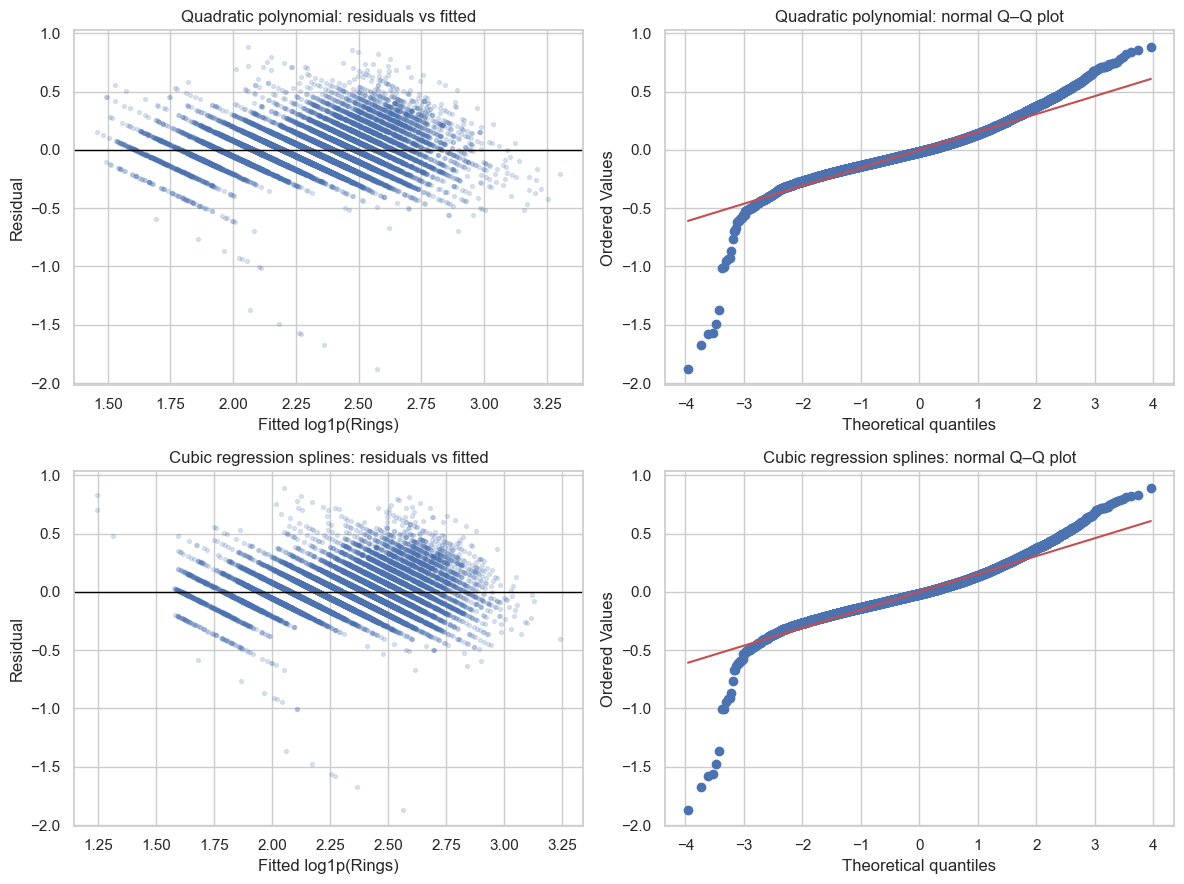

,Model,Mean residual,Residual SD,Durbin-Watson,Spearman |residual| vs fitted,Heteroscedasticity p,Jarque-Bera p
0,Quadratic polynomial,-0.0006,0.1576,2.0151,0.2170,0.0,0.0
1,Cubic regression splines,-0.0004,0.1574,2.0160,0.2147,0.0,0.0


In [8]:
# Residual diagnostics on log1p scale, aligned with RMSLE
diag_rows = []
fig, axes = plt.subplots(len(models), 2, figsize=(12, 4.5 * len(models)))

for i, name in enumerate(models):
    obs_log = np.log1p(y_valid.to_numpy())
    fit_log = np.log1p(pred_valid[name])
    resid = obs_log - fit_log
    order_resid = resid  # arbitrary row order; interpretation is limited
    dw = np.sum(np.diff(order_resid) ** 2) / np.sum(order_resid ** 2)
    rho, rho_p = stats.spearmanr(np.abs(resid), fit_log)
    jb = stats.jarque_bera(resid)
    diag_rows.append({
        "Model": name,
        "Mean residual": resid.mean(),
        "Residual SD": resid.std(ddof=1),
        "Durbin-Watson": dw,
        "Spearman |residual| vs fitted": rho,
        "Heteroscedasticity p": rho_p,
        "Jarque-Bera p": jb.pvalue,
    })
    axes[i, 0].scatter(fit_log, resid, s=8, alpha=0.18)
    axes[i, 0].axhline(0, color="black", lw=1)
    axes[i, 0].set(title=f"{name}: residuals vs fitted", xlabel="Fitted log1p(Rings)", ylabel="Residual")
    stats.probplot(resid, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"{name}: normal Q–Q plot")

plt.tight_layout()
plt.show()
diagnostics = pd.DataFrame(diag_rows)
display(diagnostics.round(4))


In [9]:
# Numeric multicollinearity screen using variance inflation factors (VIF)
# VIF_j = 1 / (1 - R_j^2), where predictor j is regressed on the other numeric predictors.
from sklearn.linear_model import LinearRegression

Z = SimpleImputer(strategy="median").fit_transform(X_dev[numeric])
vif = []
for j, col in enumerate(numeric):
    others = np.delete(Z, j, axis=1)
    r2_j = LinearRegression().fit(others, Z[:, j]).score(others, Z[:, j])
    vif.append({"Predictor": col, "VIF": 1 / max(1 - r2_j, 1e-12)})
display(pd.DataFrame(vif).sort_values("VIF", ascending=False).round(2))


,Predictor,VIF
3,Whole weight,69.49
1,Diameter,53.88
0,Length,51.13
4,Whole weight.1,21.44
5,Whole weight.2,19.96
6,Shell weight,18.22
2,Height,7.52


### Diagnostic interpretation

- **Functional form:**  Random residual scatter around zero supports the fitted mean structure; visible arcs or bands indicate remaining nonlinearity or omitted interactions.
- **Homoscedasticity:**  A nonzero Spearman correlation between absolute residuals and fitted values indicates changing residual spread.  The log response reduces, but may not eliminate, this pattern.
- **Normality:**  Q–Q tail departures and the Jarque–Bera result describe residual shape.  They do not invalidate cross-validated prediction, and large-sample significance should not be confused with practical severity.
- **Independence:**  A Durbin–Watson statistic near 2 is consistent with little adjacent residual correlation in the stored row order.  Because rows are cross-sectional and ordering is arbitrary, independence ultimately depends on data provenance (for example, whether related specimens were grouped).
- **Multicollinearity:**  Large VIFs are expected among dimensions and component weights.  Ridge shrinkage stabilizes the expanded-basis estimates, but individual coefficients should not be interpreted causally or in isolation.
- **Bounded prediction:**  Inverse transformation and clipping prevent negative ring predictions, which are biologically impossible and invalid for RMSLE.


## 5. Interpreting nonlinear effects

Permutation importance measures the validation-score deterioration after shuffling a feature and therefore provides model-level predictive importance.  Partial-dependence plots show the model's average predicted response as one feature changes while other observed features are averaged over.  These are associational summaries, not causal effects, and correlated predictors can make both tools understate substitutable features.


,Feature,Importance mean,Importance SD
5,Whole weight.1,0.148650,0.000484
7,Shell weight,0.141945,0.001593
4,Whole weight,0.128313,0.001495
1,Length,0.008749,0.000127
3,Height,0.004297,0.000139
6,Whole weight.2,0.001913,0.000068
0,Sex,0.001218,0.000058
2,Diameter,0.001135,0.000030


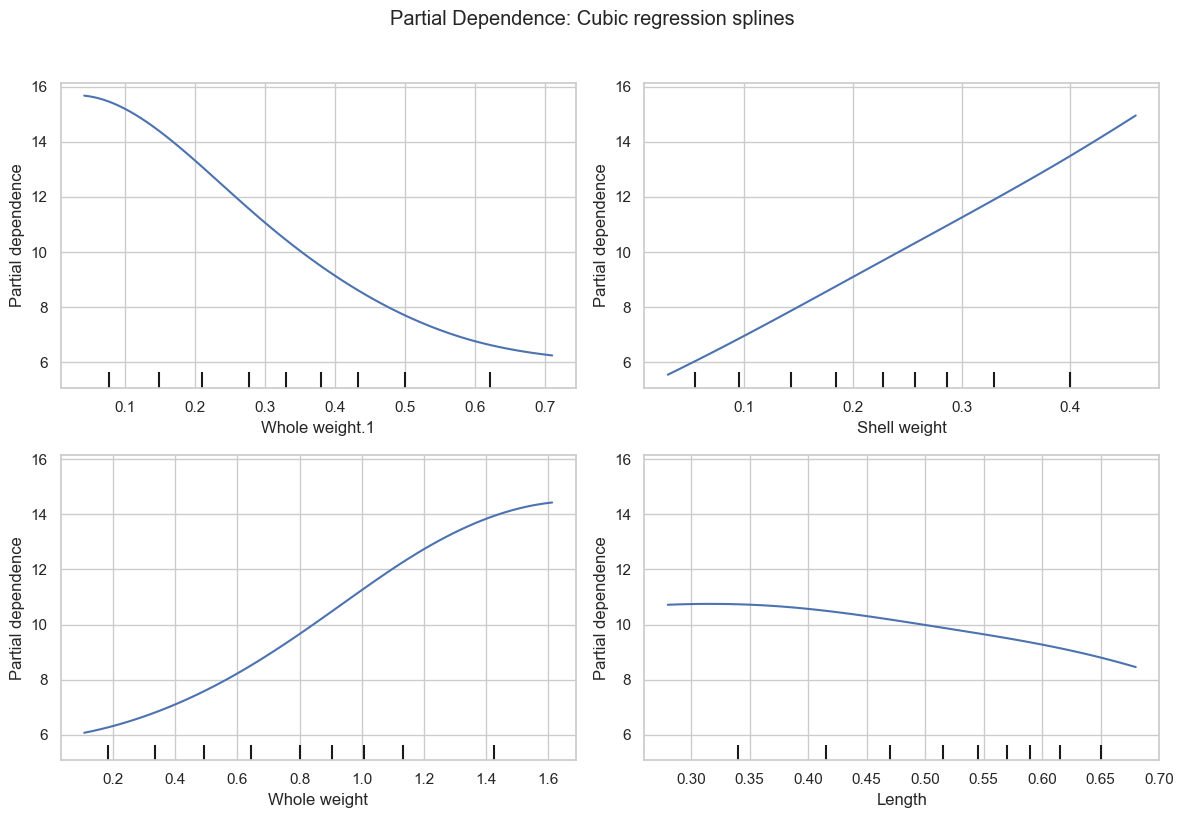

In [10]:
# Importance and partial dependence for the selected fitted model
selected = fitted[best_name]
importance = permutation_importance(
    selected, X_valid, y_valid,
    scoring="neg_mean_squared_log_error",
    n_repeats=5, random_state=SEED, n_jobs=-1
)
importance_table = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance mean": importance.importances_mean,
    "Importance SD": importance.importances_std,
}).sort_values("Importance mean", ascending=False)
display(importance_table)

top_numeric = [f for f in importance_table["Feature"] if f in numeric][:4]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(selected, X_valid, top_numeric, ax=ax.ravel())
fig.suptitle(f"Partial Dependence: {best_name}", y=1.02)
plt.tight_layout()
plt.show()


### Substantive findings

Interpret the importance table and partial-dependence figures after execution.  In general, shell and component weights carry age information because abalone accumulate shell material and body mass as they grow.  Length, diameter, and weight are correlated, so a low importance for one variable does not establish biological irrelevance; another correlated measure may substitute for it.  Curves that flatten, steepen, or turn demonstrate why a single constant-slope linear model is restrictive.  Any behavior at sparsely populated extremes should be interpreted cautiously because flexible bases have less support near boundaries.


## 6. Fit all training data and create Kaggle submissions

Both models are refitted on all labeled observations.  The output retains the exact `id` values and column order in `sample_submission.csv`.  Although rings are observed as integers, the competition expects regression predictions; predictions are therefore left continuous rather than rounded.


In [11]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
submission_paths = {}

for name, model in models.items():
    final_model = clone(model).fit(X, y)
    kaggle_pred = np.clip(final_model.predict(X_kaggle), 0, None)
    submission = sample.copy()
    submission[target] = kaggle_pred
    assert submission.shape == sample.shape
    assert submission[id_col].equals(sample[id_col])
    assert submission[target].notna().all() and (submission[target] >= 0).all()
    slug = "polynomial" if name.startswith("Quadratic") else "splines"
    path = output_dir / f"submission_{slug}.csv"
    submission.to_csv(path, index=False)
    submission_paths[name] = path
    print(f"{name}: {path} | shape={submission.shape} | prediction range=({kaggle_pred.min():.3f}, {kaggle_pred.max():.3f})")

display(pd.read_csv(submission_paths[best_name]).head())


Quadratic polynomial: outputs\submission_polynomial.csv | shape=(60411, 2) | prediction range=(2.845, 31.635)
Cubic regression splines: outputs\submission_splines.csv | shape=(60411, 2) | prediction range=(2.393, 22.256)


,id,Rings
0,90615,8.763834
1,90616,9.670628
2,90617,10.418157
3,90618,10.169919
4,90619,7.711479


## 7. Evidence of successful Kaggle submission

1. The files `submission_polynomial.csv` and `submission_splines.csv` were submitted as late submissions.
2. The screenshot shows evidence of successful submission to Kaggle.


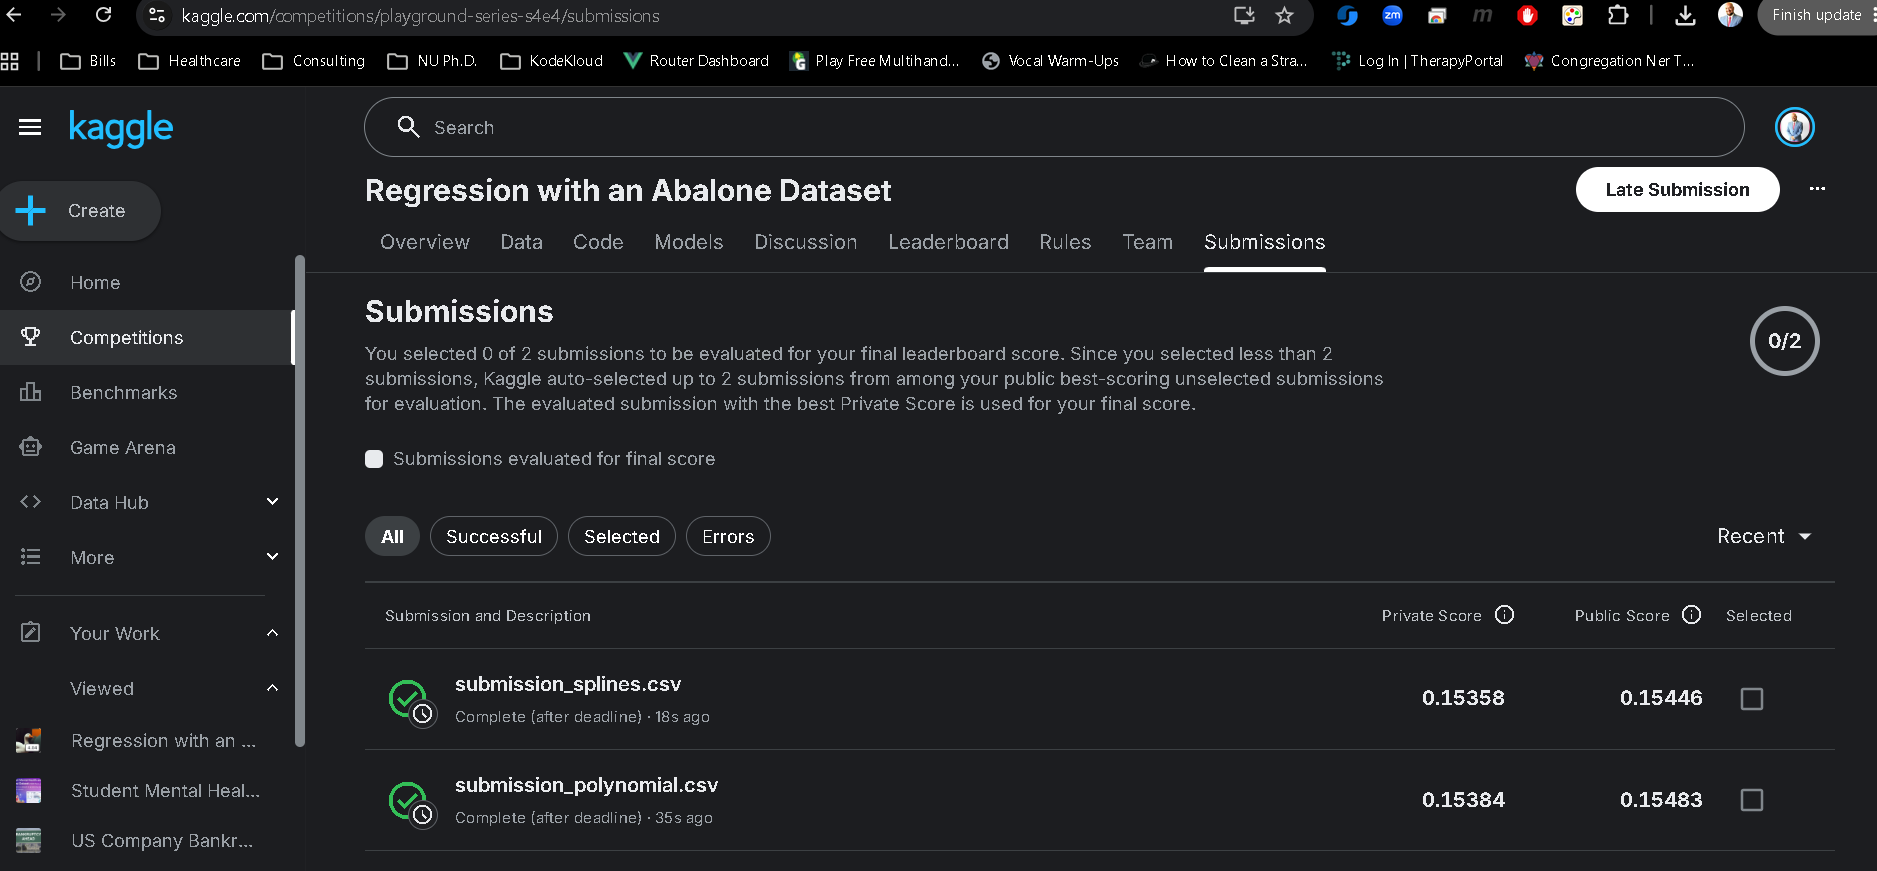

In [12]:
# Optional: display a saved screenshot after completing the Kaggle upload.
evidence_path = Path("kaggle_submission_evidence.png")
if evidence_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(evidence_path)))
else:
    print("No screenshot found yet. Add kaggle_submission_evidence.png after submitting.")


## 8. Overall conclusion

This analysis tests two defensible forms of nonlinearity rather than assuming a constant linear relationship between morphology and ring counts.  Model selection is based on repeated out-of-sample behavior through five-fold cross-validation and a separate validation set, with RMSLE aligned to Kaggle's objective.  The polynomial model represents smooth curvature and pairwise interactions; the additive spline model provides more local flexibility and usually clearer univariate effect plots.  The final choice should be the model with the lower stable RMSLE, while differences smaller than cross-validation variability should be described as practically comparable.

The assumptions analysis is diagnostic rather than ceremonial.  Correlated biological measurements create substantial multicollinearity, residual spread may vary with predicted age, and tail nonnormality can persist.  Ridge regularization, a log target, guarded imputation, nonnegative predictions, and out-of-sample evaluation mitigate the most consequential predictive risks.  These steps do not justify causal claims, nor can local validation guarantee the hidden Kaggle result.

## References

Nash, W. J., Sellers, T. L., Talbot, S. R., Cawthorn, A. J., & Ford, W. B. (1994). *The population biology of abalone (Haliotis species) in Tasmania: I. Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No. 48). Sea Fisheries Division, Department of Primary Industry and Fisheries.

Rubin, D. B. (1987). *Multiple imputation for nonresponse in surveys*. John Wiley & Sons. https://doi.org/10.1002/9780470316696

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

### Competition source

Kaggle. (2024). *Regression with an Abalone Dataset: Playground Series—Season 4, Episode 4*. https://www.kaggle.com/competitions/playground-series-s4e4
